In [ ]:
# ----- INSTALL DEPENDENCIES -----
!pip install xgboost
!pip install scikit-learn
!pip install matplotlib
!pip install pandas numpy

In [ ]:
# ----- IMPORT LIBRARIES -----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, roc_curve, classification_report, confusion_matrix)

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# ----- LOAD DATASET -----
!kaggle datasets download -d cherngs/heart-disease-cleveland-uci
!unzip -o heart-disease-cleveland-uci.zip

df = pd.read_csv("heart_cleveland_upload.csv")

Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api
100% 3.33k/3.33k [00:00<00:00, 13.9MB/s]

Archive:  heart-disease-cleveland-uci.zip
  inflating: heart_cleveland_upload.csv  


In [ ]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.apply(pd.to_numeric)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


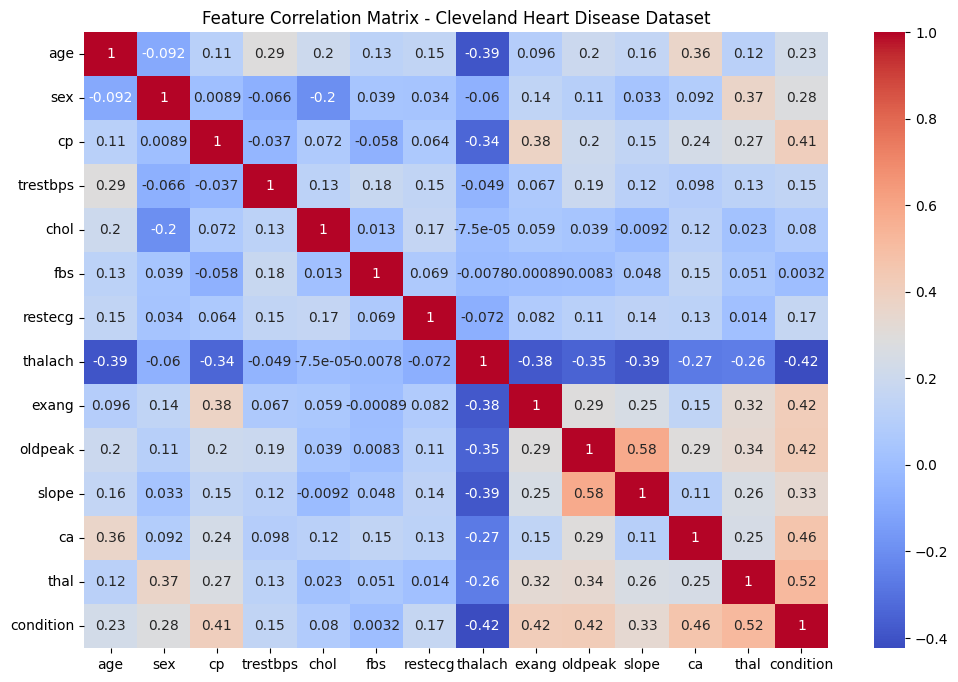

In [ ]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix - Cleveland Heart Disease Dataset')
plt.show()

In [ ]:
# ----- PREPROCESSING -----
X = df.drop('condition', axis=1)
y = df['condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# DEFINE BASE MODELS

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=1, gamma=0.01, probability=True, random_state=42))
])

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
meta_model = LogisticRegression(max_iter=1000)

In [ ]:
#BUILD HYBRID STACKING MODEL
hybrid_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    final_estimator=meta_model,
    stack_method='predict_proba',
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    passthrough=True
)
# Train hybrid model
hybrid_model.fit(X_train, y_train)
print("Hybrid model trained successfully!")

Hybrid model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# MODEL EVALUATION
y_proba = hybrid_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold:", optimal_threshold)
y_pred = (y_proba >= optimal_threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Optimal Threshold: 0.5204168588585171
Accuracy: 0.9166666666666666
Precision: 1.0
Recall: 0.8214285714285714
F1 Score: 0.9019607843137255
AUROC: 0.9441964285714286

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



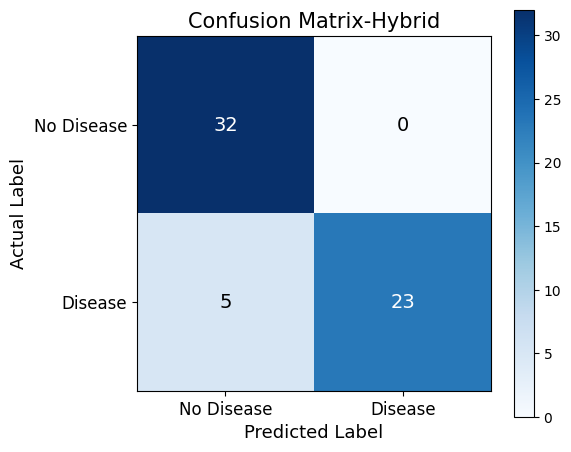

In [ ]:
#CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix-Hybrid', fontsize=15)
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.yticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)
plt.tight_layout()
plt.grid(False)
plt.show()


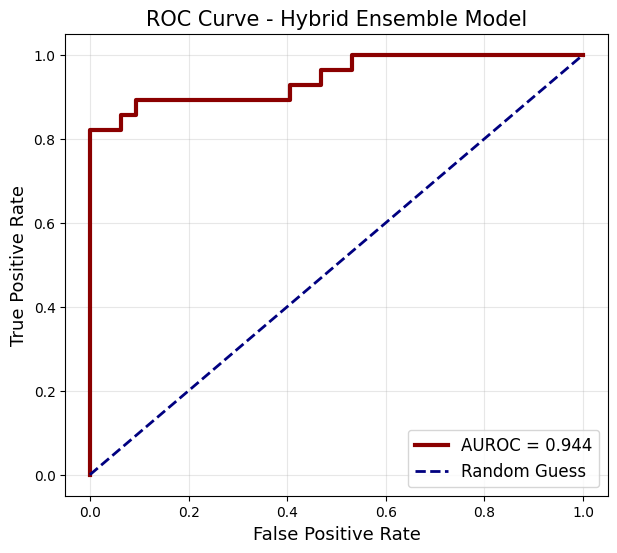

In [ ]:
#ROC CURVE
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
from sklearn.metrics import auc as sk_auc
auc_value = sk_auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, label=f'AUROC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - Hybrid Ensemble Model', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# RANDOM PATIENT PREDICTION
# ----- Predict for a random patient -----
import random
rand_index = random.randint(0, X_test.shape[0]-1)
patient_features = X_test.iloc[[rand_index]]  # Keep as DataFrame to preserve feature names
true_label = y_test.iloc[rand_index]
pred_prob = hybrid_model.predict_proba(patient_features)[0][1]
pred_class = int(pred_prob >= optimal_threshold)
print("\nRandom Patient Details:")
print(X_test.iloc[rand_index])

print("\nTrue Condition:", "Heart Disease" if true_label == 1 else "No Disease")
print(f"Predicted Probability of Heart Disease: {pred_prob*100:.2f}%")
print("Predicted Class:", "Heart Disease" if pred_class == 1 else "No Disease")


Random Patient Details:
age          59.0
sex           1.0
cp            3.0
trestbps    110.0
chol        239.0
fbs           0.0
restecg       2.0
thalach     142.0
exang         1.0
oldpeak       1.2
slope         1.0
ca            1.0
thal          2.0
Name: 208, dtype: float64

True Condition: Heart Disease
Predicted Probability of Heart Disease: 89.77%
Predicted Class: Heart Disease


In [ ]:
import joblib
import os

# Hybrid StackingClassifier — dump entire model (handles its own scaling internally)
os.makedirs('pkl_files', exist_ok=True)
joblib.dump(hybrid_model, 'pkl_files/hybrid.pkl')

# Verify
loaded = joblib.load('pkl_files/hybrid.pkl')
test_input = X_test.iloc[:1]  # Keep as DataFrame — Hybrid needs feature names
test_prob = loaded.predict_proba(test_input)[0][1]
print(f"Hybrid pkl verified. Sample prob: {test_prob:.4f}")
print(f"Optimal threshold locked: {optimal_threshold:.4f}")
print("Hybrid stacking model saved successfully.")

Hybrid pkl verified. Sample prob: 0.0865
Optimal threshold locked: 0.5204
Hybrid stacking model saved successfully.
